120


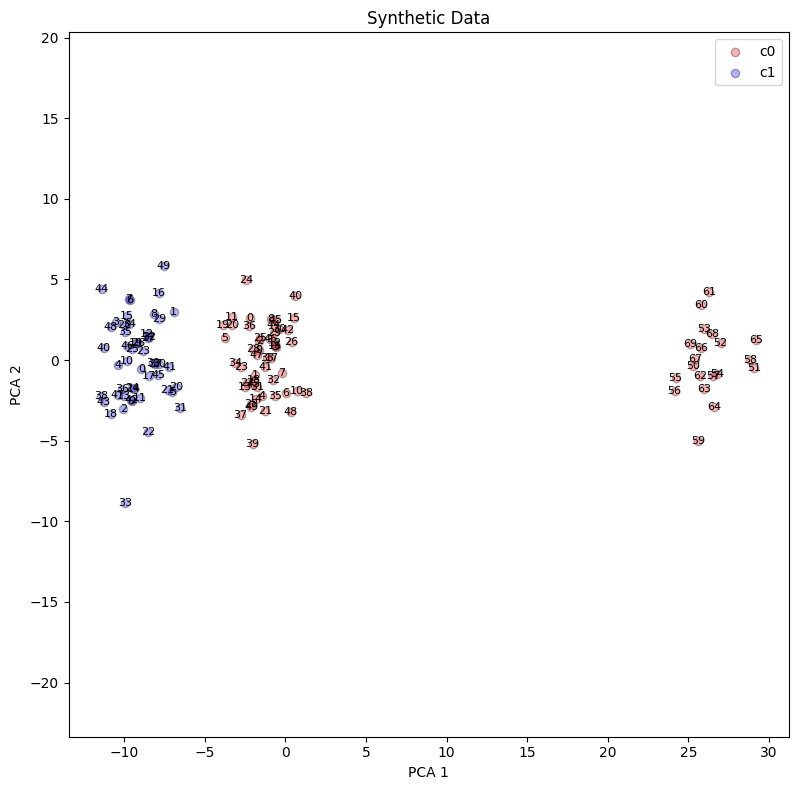

combined-data
[[ 9.43368805e-01  1.31436205e+00  1.16496540e+00 ...  3.04042298e+00
  -2.83694525e-01  6.39269088e-01]
 [ 3.12243283e-01 -1.00635219e+00  5.64841608e-01 ... -5.75432996e-01
   1.96221648e+00 -8.85449859e-01]
 [ 2.23788832e+00  1.80049835e-01  1.29887760e+00 ...  1.03528448e+00
   1.96545141e+00  2.82627802e-02]
 ...
 [-1.42209452e+00 -2.99376149e-03 -9.08109123e-01 ...  2.76786680e+00
  -1.84488296e+00 -1.33655999e+00]
 [ 5.08632893e-01 -1.78983317e+00  4.99726281e-01 ...  6.95206932e-01
  -2.48811424e-01  4.79645282e-01]
 [ 4.50666985e+00 -1.15337717e+00  3.52160175e-01 ...  7.90149005e-01
   1.54723912e+00  6.69910645e-01]]
(120, 50)
normalised
The original graph is composed of 2 connected component(s) band = 15.
normalized
The GC graph is composed of 1 connected component(s).


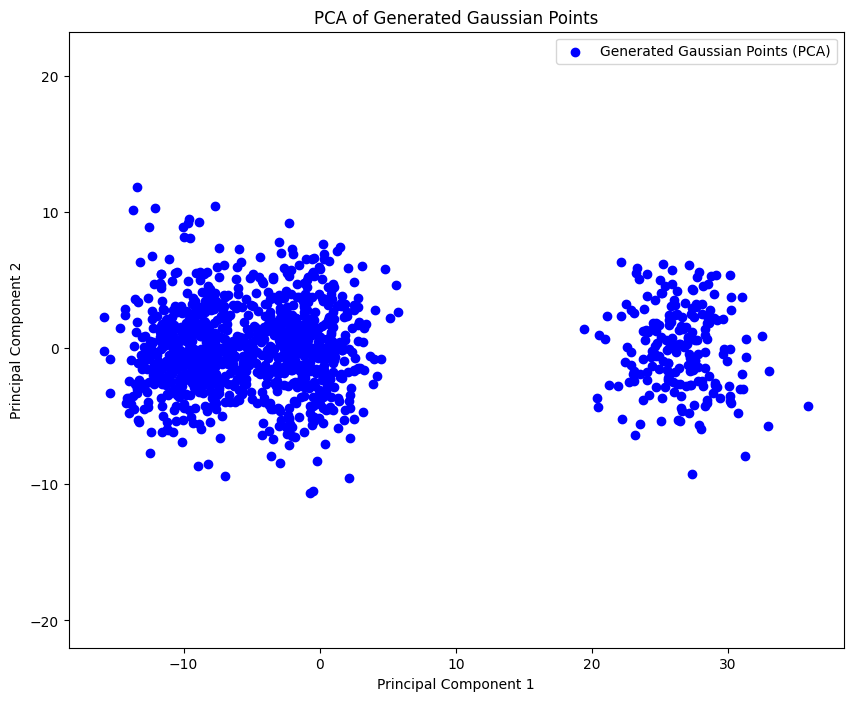

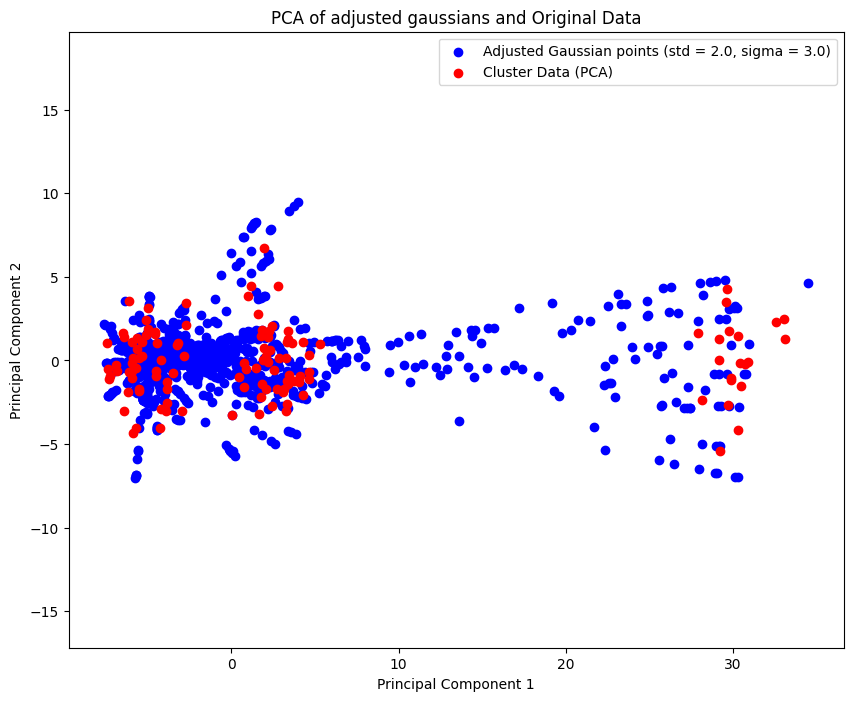

(120, 120)
(1320, 1320)


Starting computation for t=10.0 and k=10
Starting computation for t=1 and k=10
Chebyshev coefficients:
[ 1.22178309e+00 -3.36637862e-01  4.76095524e-02 -4.51908876e-03
  3.22585727e-04 -1.84467481e-05  8.79733949e-07 -3.59788856e-08
  1.28793313e-09 -4.09906974e-11  1.17433437e-12]


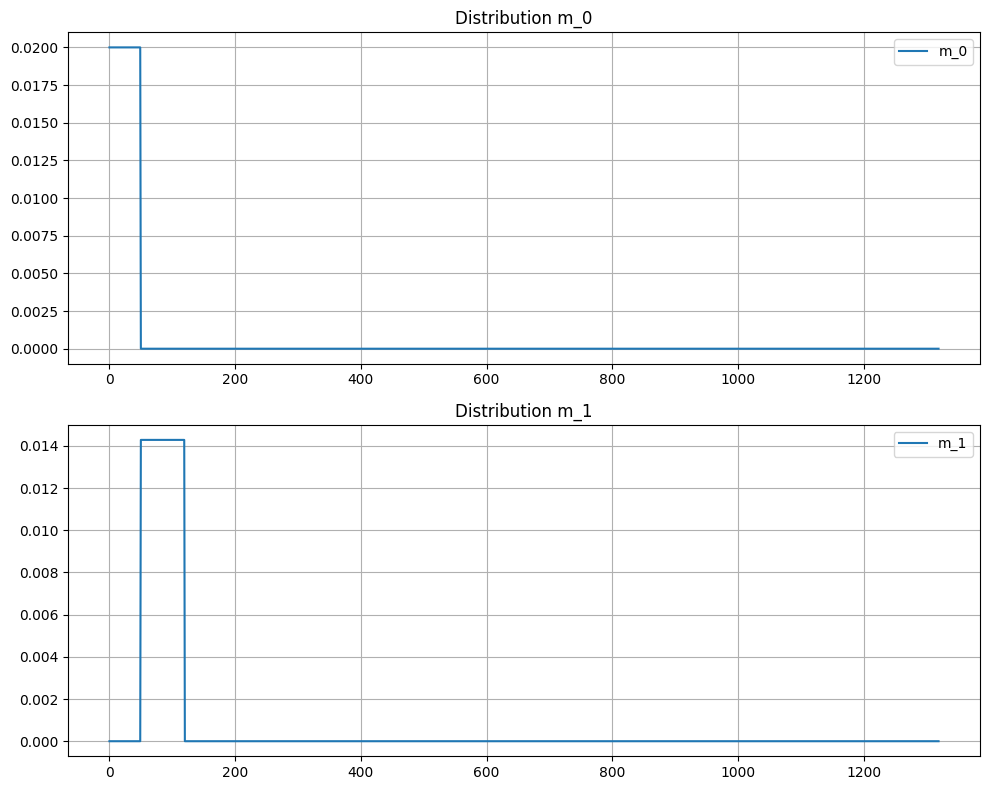

10 7.72802382453005
20 7.733761125217262
30 7.738680248000149
40 7.742862499529018
50 7.746379175029414
60 7.749291049737849
70 7.751650249781466
80 7.753501738940123
90 7.754884510043151
100 7.755832547094148
110 7.756375607887438
120 7.756539864920274
130 7.75634843358727
140 7.75582181008609
150 7.754978236495717
160 7.753834006748196
170 7.752403724343051
180 7.7507005204400095
190 7.748736239241474
200 7.746521596234487
210 7.744066313817303
220 7.741379237976034
230 7.738468439027496
240 7.735341298912871
250 7.732004587061443
260 7.728464526569507
270 7.724726852056179
280 7.7207968604366854
290 7.716679455561859
300 7.712379187594038
310 7.707900287821879
320 7.703246699498585
330 7.698422105263461
340 7.69342995152838
350 7.688273470253016
360 7.682955698405884
370 7.677479495398913
380 7.671847558738854
390 7.6660624380920055
400 7.6601265479693765
410 7.654042179156029
420 7.647811509052296
430 7.641436611029668
440 7.634919462910638
450 7.628261954681655
460 7.6214658954858

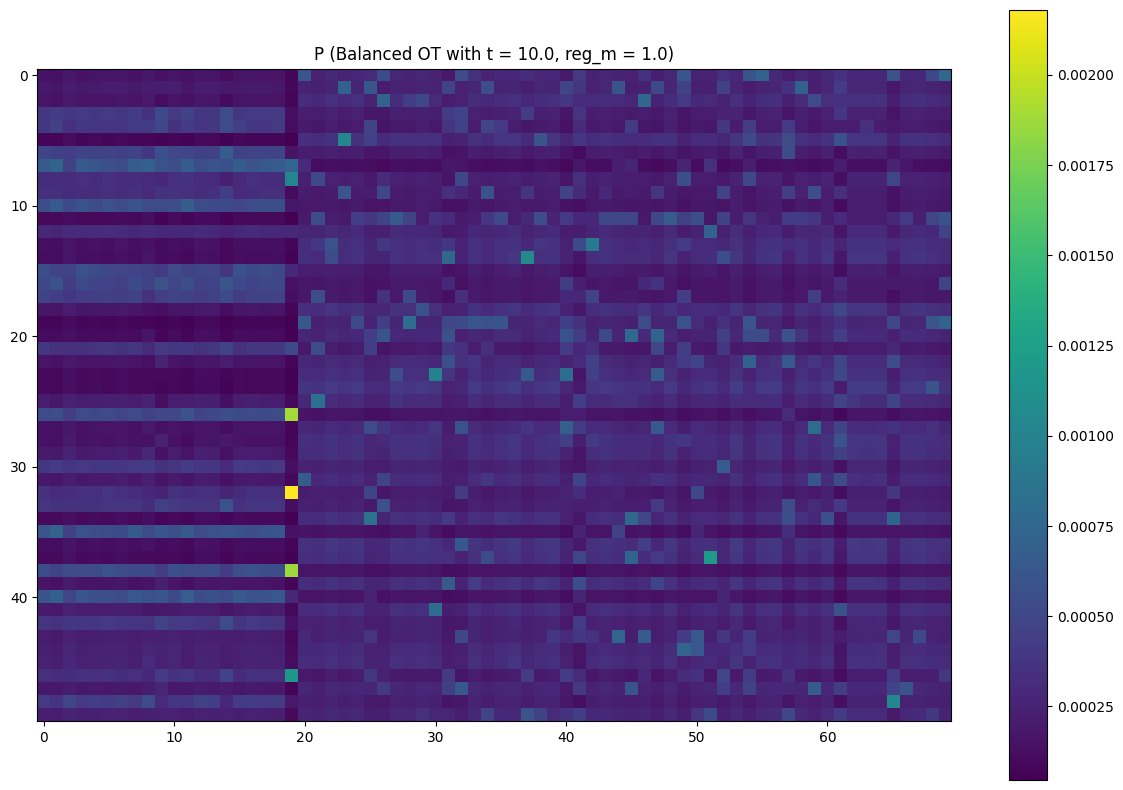

50
70
(50, 70)


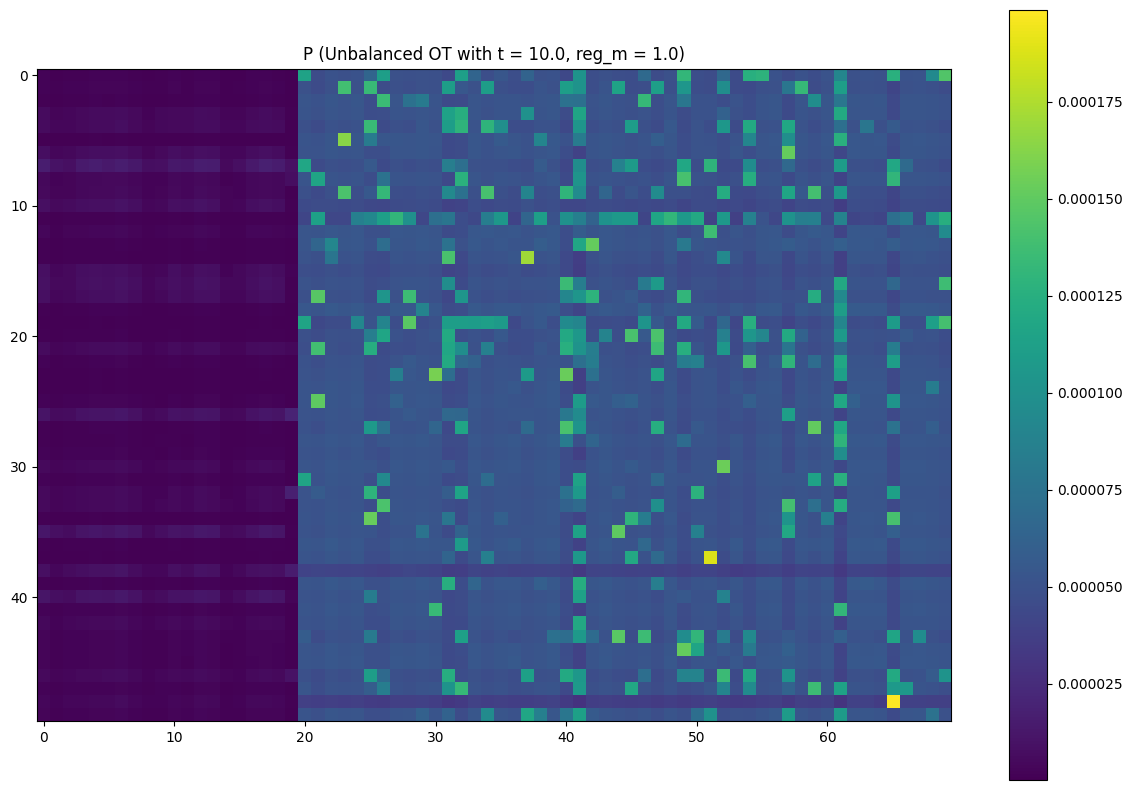

In [ ]:
import time
import signal
import sys
import convolutional_sinkhorn
import UOT_convolutional_sinkhorn
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import time
import scprep
from scipy.sparse.linalg import eigsh 
from scipy.special import ive  
import graphtools
from scipy.sparse.linalg import eigsh 
from scipy.sparse.csgraph import connected_components
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances



start_time = time.time()
RESULT_FILE = '/Users/x/Documents/AD015/condition_matrix_1st_rep.csv'


import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_pca(*c_arrays):
    """
    Perform PCA on an arbitrary number of arrays and plot the results.
    
    Parameters:
    *c_arrays: Variable number of numpy arrays to analyze
    """
    # Stack all arrays vertically
    all_data = np.vstack(c_arrays)
    
    colors = ['red', 'blue']
    labels = []
    for i, arr in enumerate(c_arrays):
        labels.extend([i] * len(arr))
    

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(all_data)

    plt.figure(figsize=(8, 8))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(c_arrays)))
    colors = ['red', 'blue']
    for i, arr in enumerate(c_arrays):
        idx = np.array(labels) == i
        plt.scatter(pca_result[idx, 0], pca_result[idx, 1], 
                   label=f'c{i}', alpha=0.3, color=colors[i], edgecolor='k')
        # Add numbers to each point
        start_idx = sum(len(a) for a in c_arrays[:i])
        for j in range(len(arr)):
            x, y = pca_result[start_idx + j, 0], pca_result[start_idx + j, 1]
            plt.text(x, y, str(j), fontsize=8, ha='center', va='center')
            
    '''
    for i, color in enumerate(colors):
        idx = np.array(labels) == i
        plt.scatter(pca_result[idx, 0], pca_result[idx, 1], 
                   label=f'c{i}', alpha=0.3, color=color, edgecolor='k')
    '''
    
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title(f'Synthetic Data')
    plt.legend()
    plt.tight_layout() 
    plt.axis('equal')
    #plt.savefig(f'/Users/x/Documents/POT_unbalanced/connect_like_&_UOT/PCA.png', dpi=500, bbox_inches='tight', transparent=True)
    plt.show()
    
    '''

    plt.figure(figsize=(6, 6))
    for i, arr in enumerate(c_arrays):
        # Plot the points
        plt.scatter(arr[:, 0], arr[:, 1], label=f'c{i}', alpha=0.6, edgecolor='k')
        
        # Add numbers to the LHS of each point   
        for j, (x, y) in enumerate(arr):
            plt.text(x - 0.01, y, str(j), fontsize=8, ha='right', va='center')  # Shift left by 0.1 units

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Synthetic Data')
    plt.legend()
    plt.tight_layout()
    plt.show()
    '''

# Function to save results and exit on SIGTERM
def save_results_and_exit(signum, frame):
    print(f"\nReceived termination signal {signum}. Saving results and exiting...")
    np.savetxt(RESULT_FILE, condition_matrix, delimiter=',', header='m_0', comments='')
    sys.exit(0)  # Ensure graceful exit


signal.signal(signal.SIGTERM, save_results_and_exit)  # Catches SGE job termination
signal.signal(signal.SIGUSR1, save_results_and_exit)  # Optional custom signal


def compute_chebychev_coeff_all(phi, tau, K):
    return 2 * ive(np.arange(0, K + 1), -tau * phi)


def generate_gaussian_points(data, n_points, mean=0, std=0.5):
    gaussian_points = []
    for point in data:
        gaussian_points.append(np.random.normal(loc=point, scale=std, size=(n_points, len(point))))
    return np.array(gaussian_points)


def synthetic_data_generation(points,features,x0,xn, d0, dn, random_state=42):
    rng = np.random.default_rng(random_state)
    n = np.random.uniform(x0, xn)
    m = np.random.uniform(d0,dn)
    generated_data = np.random.normal(n,m,(points,features))
    return generated_data


def build_affinity_matrix(O,N,sigma=1.0):
    dist_NO = pairwise_distances(N,O, squared= True)
    dist_ON = dist_NO.T

    K_NO = np.exp(-dist_NO/(2*sigma**2)) # inner 2 was changed from 3
    K_ON = np.exp(-dist_ON/(2*sigma**2))
    K_NN = K_NO @ K_ON
    return K_NN


def sort_swiss(data, label):
    distances = np.linalg.norm(data, axis=1)
    sorted_idx = np.argsort(distances)
    return data[sorted_idx], label[sorted_idx]

def generate_gaussian(data, num_gauss_points, std=0.5):
    gaussian_points = []
    for point in data:
        points = np.random.normal(loc=point, scale = std, size =(num_gauss_points, len(point)))
        gaussian_points.append(points)
    return np.vstack(gaussian_points)



def graph_connectivity(O, N, K_NN, t):
    D = np.diag(np.sum(K_NN, axis=1))
    epsilon = 1e-8  # Small value to avoid division by zero
    D += np.eye(D.shape[0]) * epsilon
    P_NN = np.linalg.inv(D) @ K_NN
    P_NN_powered = np.linalg.matrix_power(P_NN, t)
    N_graph_connectivity = P_NN_powered @ N
    all_points = np.vstack([O, N_graph_connectivity])
    return N_graph_connectivity, all_points


def main():
    global condition_matrix  # Ensure access to the global variable

    try:
        
        condition_sizes = [50,70]
        total_num_cells = np.sum(condition_sizes)
        print(total_num_cells)
        N = 2
        num_features = 50 # Number of features per cell  
        conditions =[]
        
        c0 = synthetic_data_generation(50, num_features, 1.0, 1.0, 1.5, 1.5) 
        c1 = synthetic_data_generation(50, num_features, 0, 0, 1.5,1.5)
        outliers = synthetic_data_generation(20, num_features,5.0, 5.0, 1.5,1.5)
  
        c0 = np.vstack([c0, outliers])
        conditions.append(c0)
        conditions.append(c1)   
             
        plot_pca(c0, c1)

        K = 0
        cs = np.vstack(conditions)
        
        print('combined-data')
        print(cs)
        print(np.shape(cs)) 

        
        t_list = [10.0]
        k_list = [10]
        band_list = [15]
        reg_m_list = [1.0] # [1.0, 5.0, 10.0, 20.0]
        num_gauss_points = 10 # 50
        t = 1
        
        sigma_l = [3.0]  
        std_l =  [2.0] 
        
        for band in band_list:
                    
            graph = graphtools.Graph(cs, use_pygsp=True, knn=1, bandwidth=band, n_jobs=-1)
            graph.compute_laplacian("normalized")  # Compute normalized Laplacian
            print('normalised')
            L_cs = graph.L
            
            #plt.figure(figsize=(12, 8))
            #im_p = plt.imshow(L_cs, cmap='viridis')
            #plt.title(f'Laplacian (Unadjusted)')
            #plt.colorbar(im_p)
            #plt.tight_layout() 
            #plt.show()  
            
            n_components, labels = connected_components(csgraph=L_cs, directed=False, connection='weak')
            print(f"The original graph is composed of {n_components} connected component(s) band = {band}.")
        
        
        
        for sigma in sigma_l:
            for std in std_l:
                
                generated_points = generate_gaussian(cs, num_gauss_points, std)
                affinity_matrix = build_affinity_matrix(O = cs, N = generated_points, sigma = sigma)   
                N_graph_connectivity, all_points = graph_connectivity(cs, generated_points, affinity_matrix, 1)
                marginal_size = all_points.shape[0]
                # marginal_size = 100
            
                for band in band_list:
                   
                    graph = graphtools.Graph(all_points, use_pygsp=True, knn=1, bandwidth=band, n_jobs=-1)
                    graph.compute_laplacian("normalized")  # Compute normalized Laplacian
                    print('normalized')
                    L_connect = graph.L
                    n_components, labels = connected_components(csgraph=L_connect, directed=False, connection='weak')
                    print(f"The GC graph is composed of {n_components} connected component(s).")
                    
                    
                    
                    if n_components == 1:
                        pca_generated = PCA(n_components=2)
                        generated_points_pca = pca_generated.fit_transform(generated_points)
                        pca = PCA(n_components=2)
                        combined_data = np.vstack([N_graph_connectivity, cs])
                        pca_result = pca.fit_transform(combined_data)
                        N_graph_connectivity_pca = pca_result[:len(N_graph_connectivity)]
                        original_data_pca = pca_result[len(N_graph_connectivity):]
            
                        plt.figure(figsize=(10, 8))
                        plt.scatter(generated_points_pca[:, 0], generated_points_pca[:, 1], label='Generated Gaussian Points (PCA)', c='blue')
                        plt.xlabel('Principal Component 1')
                        plt.ylabel('Principal Component 2')
                        plt.axis('equal')
                        plt.legend()
                        plt.title('PCA of Generated Gaussian Points')
                        #plt.savefig(f'/Users/x/Documents/POT_unbalanced/connect_like_&_UOT/PCA_generated_points_25_07_25.png', dpi=500, bbox_inches='tight', transparent=True)
                        plt.show()
                        
                        plt.figure(figsize=(10, 8))
                        plt.scatter(N_graph_connectivity_pca[:, 0], N_graph_connectivity_pca[:, 1], label=f'Adjusted Gaussian points (std = {std}, sigma = {sigma})', c='blue')
                        plt.scatter(original_data_pca[:, 0], original_data_pca[:, 1], label='Cluster Data (PCA)', c='red')
                        plt.xlabel('Principal Component 1')
                        plt.ylabel('Principal Component 2')
                        plt.axis('equal')
                        plt.legend()
                        plt.title('PCA of adjusted gaussians and Original Data')
                        # plt.savefig(f'/Users/x/Documents/POT_unbalanced/connect_like_&_UOT/connect_like_adjusted_PCA_std{std}_sigma{sigma}_25_07_25.png', dpi=500, bbox_inches='tight', transparent=True)
                        plt.show()
                 
                        for k in k_list:
                            for t_GS in t_list:
                                for reg_m in reg_m_list:
                                    print(L_cs.shape)
                                    print(L_connect.shape)

                                    print(f"\n\nStarting computation for t={t_GS} and k={k}")
                                    condition_matrix_balanced = np.zeros((N,N))
                                    condition_matrix_unbalanced = np.zeros((N,N))
                                    
                                    print(f"Starting computation for t={t} and k={k}")

                                    phi = eigsh(L_connect, k=k, return_eigenvectors=False)[0] / 2  # Compute the largest eigenvalue divided by 2
                                    coeff = compute_chebychev_coeff_all(phi, t, k)  # Compute Chebyshev coefficients
                                    print("Chebyshev coefficients:")
                                    print(coeff)
                                    M = L_connect.shape[0]
                                    a = np.ones(M) / M
                                
                                    for A, _ in enumerate(conditions):
                                        for B, _ in enumerate(conditions): 
                                            if B > A:
                                                start_A = sum(condition_sizes[:A])
                                                end_A = start_A + condition_sizes[A] - 1
                                                start_B = sum(condition_sizes[:B])
                                                end_B = start_B + condition_sizes[B] - 1

                                                m_0 = np.zeros(marginal_size,)
                                                m_0[start_A:end_A+1] = 1
                                                m_0 = m_0 / np.sum(m_0) 
                                            
                                                m_1 = np.zeros(marginal_size,)
                                                m_1[start_B:end_B+1] = 1
                                                m_1 = m_1 / np.sum(m_1)
                                                
                                                fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
                                                ax1.plot(m_0, label='m_0')
                                                ax1.set_title('Distribution m_0')
                                                ax1.legend()
                                                ax1.grid()
                                                ax2.plot(m_1, label='m_1')
                                                ax2.set_title('Distribution m_1')
                                                ax2.legend()
                                                ax2.grid()
                                                plt.tight_layout()
                                                plt.show()
                                            
                                                dist_w, P = convolutional_sinkhorn.fastcheb_conv_sinkhorn(L_connect, m_0, m_1, phi, coeff, t=t_GS, k=k, verbose = True,  P=K)
                                                print ('Balanced OT: dist_w for condition',A, 'and condition', B,' = ', dist_w)
                                                dist_w = max(dist_w, 0)
                                                
                                                condition_matrix_balanced[A, B] = dist_w
                                                condition_matrix_balanced[B, A] = dist_w
                                                
                                                start_A_UOT = sum(condition_sizes[:A])
                                                end_A_UOT = start_A_UOT + condition_sizes[A] - 1
                                                start_B_UOT = sum(condition_sizes[:B])
                                                end_B_UOT = start_B_UOT + condition_sizes[B] - 1

                                                m_0_UOT = np.zeros(marginal_size,)
                                                m_0_UOT[start_A_UOT:end_A_UOT+1] = 1
                                                m_1_UOT = np.zeros(marginal_size,)
                                                m_1_UOT[start_B_UOT:end_B_UOT+1] = 1
                                                
                                            
                                                dist_w_UOT, P_UOT = UOT_convolutional_sinkhorn.fastcheb_conv_sinkhorn(L_connect, m_0_UOT, m_1_UOT, phi, coeff,reg_m, t=t, k=k, verbose = True, P=K)
                                                print ('Unbalanced OT: dist_w for condition',A, 'and condition', B,' = ', dist_w)
                                                dist_w_UOT = max(dist_w_UOT, 0)

                                                condition_matrix_unbalanced[A, B] = dist_w_UOT
                                                condition_matrix_unbalanced[B, A] = dist_w_UOT
                                                
                                        
                                                P_norm = P * a
                                                P_norm_UOT = P_UOT * a

                                                print(condition_sizes[0])
                                                print(condition_sizes[1])
                                                
                                                P_norm_cropped = P_norm[:condition_sizes[0], condition_sizes[0]:total_num_cells]
                                                P_norm_cropped_UOT = P_norm_UOT[:condition_sizes[0], condition_sizes[0]:total_num_cells]
                                                
                                                vmin = np.min(P_norm_cropped)
                                                vmax = np.max(P_norm_cropped)
                                                print(P_norm_cropped.shape)
                                         
                                                plt.figure(figsize=(12, 8))
                                                im_p = plt.imshow(P_norm_cropped, cmap='viridis', vmin = vmin, vmax = vmax)
                                                plt.title(f'P (Balanced OT with t = {t_GS}, reg_m = {reg_m})')
                                                plt.colorbar(im_p)

                                                plt.tight_layout() 
                                                #plt.savefig(f'/Users/x/Documents/POT_unbalanced/connect_like_&_UOT/transport_plans_same_scale_t{t}_regm{reg_m}_25_07_25.png', dpi=500, bbox_inches='tight', transparent=True)
                                                plt.show()
                                                
                                                
                                                print(condition_sizes[0])
                                                print(condition_sizes[1])
                                                
                                               
                                                vmin = np.min(P_norm_cropped_UOT)
                                                vmax = np.max(P_norm_cropped_UOT)
                                                print(P_norm_cropped_UOT.shape)
                                                plt.figure(figsize=(12, 8))
                                                im_p = plt.imshow(P_norm_cropped_UOT, cmap='viridis', vmin = vmin, vmax = vmax)
                                                plt.title(f'P (Unbalanced OT with t = {t_GS}, reg_m = {reg_m})')
                                                plt.colorbar(im_p)

                                                plt.tight_layout() 
                                                #plt.savefig(f'/Users/x/Documents/POT_unbalanced/connect_like_&_UOT/transport_plans_same_scale_t{t}_regm{reg_m}_25_07_25.png', dpi=500, bbox_inches='tight', transparent=True)
                                                plt.show()  

         
    except KeyboardInterrupt:
        print("\nJob interrupted manually (CTRL+C). Saving results...")
        np.savetxt(RESULT_FILE, condition_matrix, delimiter=',', comments='')


if __name__ == '__main__':
    main()